# Ярус B: ResNet-18 и ViT-Tiny на CIFAR-10/100

Сетка $(\eta, \lambda)$, критерии на всей сети, чувствительность к $\beta_2$
и обобщение при равном train loss. Все ячейки читают сохранённые результаты
(`theory_bench/results/dl/*.json`).

Перезапуск: `bash theory_bench/run_b1_grid.sh <gpu>`, `bash theory_bench/run_b4_tune.sh <gpu>`.

In [1]:
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RES = "../theory_bench/results"
FIGS = "../theory_bench/figs"
pd.set_option("display.precision", 4)

def show(name, width=900):
    display(Image(filename=os.path.join(FIGS, name), width=width))
DL = f"{RES}/dl"

## B1. Heatmap $(\eta, \lambda)$: развязка у AdamW

90 прогонов ResNet-18/CIFAR-10. У AdamW качество нечувствительно к $\lambda$ на пяти
порядках; у AdamL2 оптимум диагонален; AdamWH обрушивается вдоль $\eta\lambda \approx \mathrm{const}$.

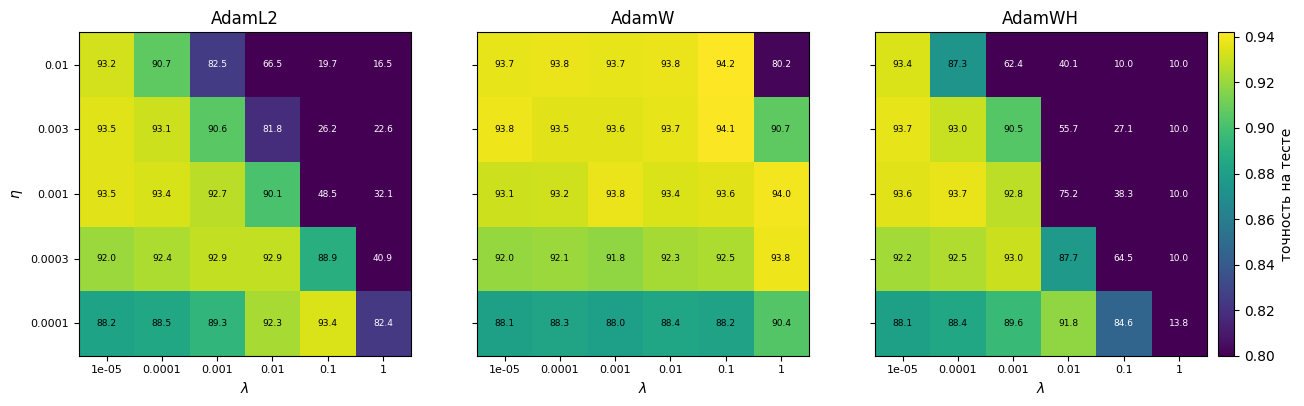

лучшие: {'AdamL2': {'best_acc': 0.9355, 'lr': 0.001, 'wd': 1e-05}, 'AdamW': {'best_acc': 0.942, 'lr': 0.01, 'wd': 0.1}, 'AdamWH': {'best_acc': 0.9373, 'lr': 0.001, 'wd': 0.0001}}


In [2]:
s = json.load(open(f"{DL}/b1_summary.json"))
lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]; wds = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
names = {"l2": "AdamL2", "w": "AdamW", "wh": "AdamWH"}
acc = {m: np.array(s["acc_grid"][m]) for m in names}
vmax = max(np.nanmax(a) for a in acc.values())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for k, m in enumerate(names):
    ax = axes[k]
    im = ax.imshow(acc[m], origin="lower", aspect="auto", vmin=0.80, vmax=vmax, cmap="viridis")
    ax.set_xticks(range(len(wds))); ax.set_xticklabels([f"{w:g}" for w in wds], fontsize=8)
    ax.set_yticks(range(len(lrs))); ax.set_yticklabels([f"{l:g}" for l in lrs], fontsize=8)
    ax.set_xlabel(r"$\lambda$");  ax.set_title(names[m])
    if k == 0: ax.set_ylabel(r"$\eta$")
    for i in range(len(lrs)):
        for j in range(len(wds)):
            ax.text(j, i, f"{100*acc[m][i,j]:.1f}", ha="center", va="center", fontsize=6.5,
                    color="white" if acc[m][i,j] < 0.5*(0.80+vmax) else "black")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, label="точность на тесте")
plt.show()
print("лучшие:", {names[m]: s["best"][m] for m in names})

## Критерии на всей сети (лучший AdamW, 3 сида)

$\|\nabla F\|^2$ выходит на плато, $\|\nabla \widetilde F_t\|^2$ убывает вместе с $\|\nabla f\|^2$.

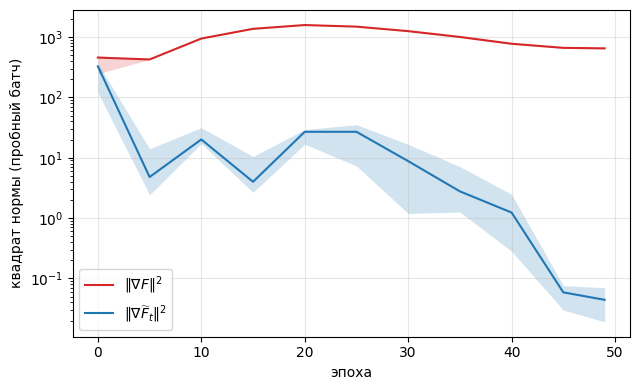

финальное отношение критериев по сидам: ['33410', '9261', '14806']


In [3]:
runs = []
for sd in (0, 1, 2):
    d = json.load(open(f"{DL}/b1_w_lr0.01_wd0.1_s{sd}.json"))
    eps = sorted(d["diag"], key=int)
    runs.append(([int(e) for e in eps],
                 [d["diag"][e]["global"]["gF2"] for e in eps],
                 [d["diag"][e]["global"]["gFt2"] for e in eps]))
x = runs[0][0]
fig, ax = plt.subplots(figsize=(6.5, 4))
for idx, color, lbl in ((1, "tab:red", r"$\|\nabla F\|^2$"), (2, "tab:blue", r"$\|\nabla \widetilde F_t\|^2$")):
    arr = np.array([r[idx] for r in runs])
    ax.fill_between(x, arr.min(0), arr.max(0), color=color, alpha=0.2, lw=0)
    ax.semilogy(x, np.median(arr, 0), color=color, label=lbl)
ax.set_xlabel("эпоха"); ax.set_ylabel("квадрат нормы (пробный батч)")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
print("финальное отношение критериев по сидам:", [f"{r[1][-1]/r[2][-1]:.0f}" for r in runs])

## B2. Плато на сети не зависит от $\beta_2$ (шумовой член доминирует)

In [4]:
rows = []
for f in sorted(glob.glob(f"{DL}/b2beta*_w_*.json")):
    d = json.load(open(f))
    eps = sorted(d["diag"], key=int)
    rows.append(dict(beta2=d["beta2"],
                     plateau_gFt2=float(np.mean([d["diag"][e]["global"]["gFt2"] for e in eps[-3:]])),
                     gF2=float(np.mean([d["diag"][e]["global"]["gF2"] for e in eps[-3:]])),
                     best_acc=d["best_acc"]))
pd.DataFrame(rows).sort_values("beta2")

,beta2,plateau_gFt2,gF2,best_acc
3,0.9000,20.6497,956.3986,0.8241
2,0.9900,53.3809,1107.8068,0.8292
1,0.9990,27.4152,1237.6819,0.8191
0,0.9999,8.3876,903.6887,0.8193


## B4. CIFAR-100: итоговая точность и срезы «равный train loss»

При равной подгонке обобщение методов близко; преимущество AdamW — прежде всего
оптимизационное (AdamL2 на ViT не достигает train loss 2.0).

In [5]:
b4 = json.load(open(f"{DL}/b4_final.json"))
tbl = pd.DataFrame({k: dict(zip(["mean", "std"], v)) for k, v in b4["table"].items()}).T
display(tbl)
print("\nсрезы (медианная точность на тесте при первом достижении train loss ≤ L):")
for k, r in b4["slices"].items():
    print(f"  {k:15s}:", {t: (round(v, 1) if v else None) for t, v in r.items()})

,mean,std
resnet18|l2,73.500,0.2668
resnet18|sgd,76.822,0.2338
resnet18|w,75.334,0.3493
resnet18|wh,73.262,0.2737
vit|l2,58.218,0.4841
vit|sgd,64.126,0.5688
vit|w,64.456,0.2928
vit|wh,15.684,1.7549



срезы (медианная точность на тесте при первом достижении train loss ≤ L):
  resnet18|l2    : {'2.5': 37.9, '2.0': 44.9, '1.5': 52.3, '1.0': 61.1}
  resnet18|sgd   : {'2.5': 30.0, '2.0': 36.8, '1.5': 49.2, '1.0': 62.8}
  resnet18|w     : {'2.5': 32.8, '2.0': 40.4, '1.5': 53.3, '1.0': 61.3}
  resnet18|wh    : {'2.5': 35.8, '2.0': 45.0, '1.5': 53.3, '1.0': 60.6}
  vit|l2         : {'3.0': 40.7, '2.5': 52.2, '2.0': None}
  vit|sgd        : {'3.0': 40.0, '2.5': 50.8, '2.0': 59.2}
  vit|w          : {'3.0': 41.4, '2.5': 51.0, '2.0': 57.9}
  vit|wh         : {'3.0': None, '2.5': None, '2.0': None}
